In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float
    summary:str

In [3]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}

In [4]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/state['runs'] +state['sixes'] 
    
    return {'bpb': bpb}

In [9]:
def calclulate_boundary_percent(state: BatsmanState):
    boundary_percent = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    
    return {'boundary_percent': boundary_percent}

In [6]:
def summary(state: BatsmanState):
    summary= f"""Strike Rate:{state['sr']}\n
    Balls per boundary - {state['bpb']} \n
    Boundary percent - {state['boundary_percent']}
    """

    return {'summary': summary}   
    

In [13]:
graph = StateGraph(BatsmanState)
graph.add_node('calculate_str',calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calclulate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_str')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')
graph.add_edge('calculate_str', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()



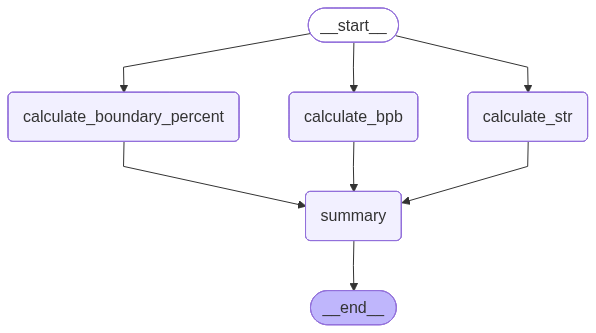

In [14]:
workflow

In [15]:
intial_state = {
    'runs': 100,
    'balls': 60,
    'fours': 10,
    'sixes': 5
}
workflow.invoke(intial_state)

{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.66666666666669,
 'bpb': 5.6,
 'boundary_percent': 70.0,
 'summary': 'Strike Rate:166.66666666666669\n\n    Balls per boundary - 5.6 \n\n    Boundary percent - 70.0\n    '}